# 01 - Exploracion de Datos Historicos en Supabase

Este notebook conecta con Supabase para verificar los datos historicos del sensor BME680.

## 1. Instalacion de dependencias

In [1]:
import sys
!{sys.executable} -m pip install -q supabase pandas python-dotenv

## 2. Configuracion de conexion

In [1]:
from supabase import create_client
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
print("Conexion a Supabase establecida")
print(f"URL: {SUPABASE_URL}")

Conexion a Supabase establecida
URL: https://mangrxgusewzgtewoayx.supabase.co


## 3. Verificacion de estructura de tabla

In [2]:
response = supabase.table("grupo1_air_quality").select("*").limit(1).execute()

if response.data:
    print("Columnas disponibles:")
    for key in response.data[0].keys():
        print(f"  - {key}")
else:
    print("No se encontraron datos en la tabla")

Columnas disponibles:
  - id
  - estacion
  - temperatura
  - humedad
  - presion
  - altura
  - gas
  - iaq
  - eco2
  - voc
  - calidad_aire
  - created_at


## 4. Carga de datos historicos

In [3]:
response = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(100).execute()

df = pd.DataFrame(response.data)
print(f"Total registros cargados: {len(df)}")
df.head(10)

Total registros cargados: 100


,id,estacion,temperatura,humedad,presion,altura,gas,iaq,eco2,voc,calidad_aire,created_at
0,327494,grupo1,12.67,54.85,647.25,3624.15,42000.0,49.26,853.24,2.91,Excelente,2026-05-24T14:14:00.498699-05:00
1,327493,grupo1,12.67,54.95,647.27,3623.91,42340.0,49.75,857.67,2.94,Excelente,2026-05-24T14:13:00.698376-05:00
2,327492,grupo1,12.68,54.96,647.24,3624.27,42254.0,49.78,858.00,2.94,Excelente,2026-05-24T14:12:00.545274-05:00
3,327491,grupo1,12.68,55.00,647.18,3624.98,42555.0,49.98,859.82,2.95,Excelente,2026-05-24T14:11:00.947141-05:00
4,327490,grupo1,12.68,55.01,647.17,3625.10,42212.0,50.05,860.42,2.95,Buena,2026-05-24T14:10:00.481434-05:00
5,327489,grupo1,12.68,55.00,647.15,3625.34,41708.0,49.98,859.80,2.95,Excelente,2026-05-24T14:09:00.570832-05:00
6,327488,grupo1,12.69,54.99,647.13,3625.58,41875.0,49.95,859.58,2.95,Excelente,2026-05-24T14:08:00.561857-05:00
7,327487,grupo1,12.69,55.02,647.09,3626.06,42254.0,50.11,861.06,2.96,Buena,2026-05-24T14:07:00.627898-05:00
8,327486,grupo1,12.70,55.00,647.05,3626.54,42085.0,49.99,859.93,2.95,Excelente,2026-05-24T14:06:00.535348-05:00
9,327485,grupo1,12.69,55.14,647.00,3627.14,42641.0,50.70,866.42,2.98,Buena,2026-05-24T14:05:00.695387-05:00


## 5. Estadisticas descriptivas

In [4]:
numeric_possible = ["temperatura", "humedad", "presion", "iaq", "eco2", "voc", "VOC", "gas", "altura"]
numeric_cols = [c for c in numeric_possible if c in df.columns]

print(f"Columnas numericas encontradas: {numeric_cols}")
if numeric_cols:
    df[numeric_cols].describe()
else:
    print("No se encontraron columnas numericas conocidas")

Columnas numericas encontradas: ['temperatura', 'humedad', 'presion', 'iaq', 'eco2', 'voc', 'gas', 'altura']


## 6. Distribucion de calidad del aire

In [5]:
if "calidad_aire" in df.columns:
    print("Distribucion de calidad_aire:")
    print(df["calidad_aire"].value_counts())
else:
    print("Columna calidad_aire no encontrada")

Distribucion de calidad_aire:
calidad_aire
Buena        72
Excelente    28
Name: count, dtype: int64


## 7. Rango temporal de los datos

In [6]:
if "created_at" in df.columns:
    df["created_at"] = pd.to_datetime(df["created_at"])
    print(f"Primer registro: {df['created_at'].min()}")
    print(f"Ultimo registro: {df['created_at'].max()}")
    print(f"Rango: {df['created_at'].max() - df['created_at'].min()}")

Primer registro: 2026-05-24 12:28:00.515103-05:00
Ultimo registro: 2026-05-24 14:14:00.498699-05:00
Rango: 0 days 01:45:59.983596


## 8. Visualizacion rapida de temperatura

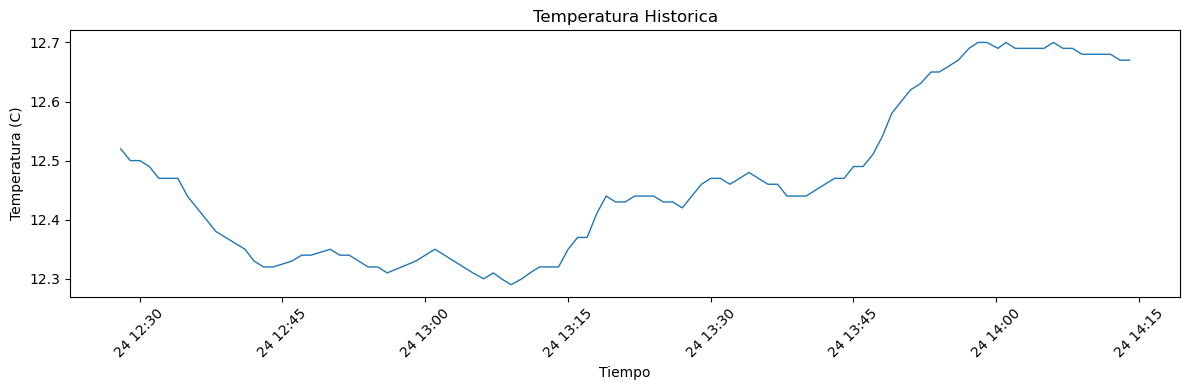

In [7]:
import matplotlib.pyplot as plt

if "created_at" in df.columns and "temperatura" in df.columns:
    df_sorted = df.sort_values("created_at")
    plt.figure(figsize=(12, 4))
    plt.plot(df_sorted["created_at"], df_sorted["temperatura"], linewidth=1)
    plt.title("Temperatura Historica")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (C)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Dato mas reciente (polling opcional)

Esta celda hace polling a Supabase para ver el ultimo registro. No es streaming real, solo verificacion puntual.

In [8]:
import time

print("Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...\n")
try:
    for i in range(6):
        resp = supabase.table("grupo1_air_quality").select("*").order("created_at", desc=True).limit(1).execute()
        if resp.data:
            d = resp.data[0]
            print(f"[{i+1}] {d.get('created_at')} | Temp: {d.get('temperatura')}C | Hum: {d.get('humedad')}% | IAQ: {d.get('iaq')}")
        time.sleep(5)
except KeyboardInterrupt:
    print("\nPolling detenido")

Obteniendo dato mas reciente cada 5 segundos (Ctrl+C para detener)...

[1] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
[2] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
[3] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
[4] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
[5] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
[6] 2026-05-24T14:15:00.595703-05:00 | Temp: 12.67C | Hum: 54.83% | IAQ: 49.17
